# 01 · Tensores con posiciones atómicas

*Mis apuntes. Sección 4 del curso (la librería PyTorch, manipulación de tensores).*

En el curso los tensores se llenaban con `torch.rand` para practicar. Yo quiero practicar lo mismo pero con algo que me sirva para la tesis: **una caja de cristal FCC con una vacancia**. Si entiendo bien este notebook, ya sé armar a mano todo lo que después le entra a una red sobre átomos.

**Qué quiero tener al final** (y para acordarme de qué es cada cosa):

| Tensor | Forma | Tipo | Qué es |
|---|---|---|---|
| `pos` | `(N, 3)` | `float32` | posición x, y, z de cada átomo, en Å |
| `species` | `(N,)` | `int64` | qué elemento es cada átomo (0 = Fe, 1 = Co, ...) |
| `edge_index` | `(2, E)` | `int64` | la lista de pares de vecinos: columna k = "el átomo `i` es vecino del `j`" |
| `x` | `(N, F)` | `float32` | rasgos de cada átomo (lo que "ve" la red) |
| `y` | `(N,)` | `float32` | lo que la red tiene que predecir: el Δv de cada átomo |

**Δv, la etiqueta.** Para cada átomo calculo su volumen de Voronoi $V_i$: la región del espacio que está más cerca de ese átomo que de cualquier otro. Después lo comparo con el volumen que tendría en el cristal perfecto:

$$\Delta v_i = \frac{V_i - V_\text{ideal}}{V_\text{ideal}}$$

Si $\Delta v_i > 0$, el átomo tiene más lugar del normal, y eso es justamente lo que pasa al lado de una vacancia.

Al final guardo todo en `datos/01_fcc_vacancia.pt` para usarlo en el 02.

## Imports: qué es cada librería

Me anoto para qué sirve cada una, porque las voy a usar en todos los notebooks:

> **`torch` (PyTorch).** La librería principal. Tiene los *tensores* (arreglos de números, como los de numpy, pero que pueden vivir en la GPU y que recuerdan las operaciones que se les hicieron para calcular gradientes) y todo lo de redes neuronales (`torch.nn`).
>
> **`numpy` (`np`).** Arreglos numéricos en CPU. Muchas librerías científicas (freud, scikit-learn, matplotlib) hablan numpy y no torch, así que voy a pasar de uno al otro seguido: `t.numpy()` y `torch.from_numpy(a)`.
>
> **`matplotlib.pyplot` (`plt`).** Para hacer gráficos: histogramas, scatter, 3D.
>
> **`freud`.** Librería de análisis de simulaciones de partículas. La uso para calcular los **volúmenes de Voronoi** respetando que la caja es periódica. Colab no la trae instalada, por eso el `try/except`: si el `import` falla, la instala con `%pip` y vuelve a importar.

`torch.manual_seed(0)` fija la semilla del generador de números aleatorios: cada vez que corro el notebook salen los mismos "desplazamientos térmicos" y los mismos resultados.

In [1]:
# En Colab torch ya viene instalado; freud (Voronoi) no.
try:
    import freud
except ImportError:
    %pip install -q freud-analysis
    import freud

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)   # reproducibilidad: misma "temperatura" en cada corrida
print("torch", torch.__version__, "| freud", freud.__version__)

torch 2.12.0+cu130 | freud 3.5.0


## Paso 1 · Armar la red FCC

Para acordarme de cómo es una red FCC (cúbica centrada en las caras): es una red cúbica donde en cada celda hay **4 átomos**, uno en el vértice y uno en el centro de tres de las caras. Esos 4 forman la **base**, en coordenadas "de celda" (fracciones del lado):

```
(0, 0, 0)   (½, ½, 0)   (½, 0, ½)   (0, ½, ½)
```

Para tener el cristal entero sumo **cada origen de celda + cada átomo de la base**. Lo hago sin loops, con *broadcasting*:

**Paso a paso de la celda de abajo:**

1. `torch.arange(n)` da `[0, 1, 2, 3]`: los índices de celda en cada eje.
2. `torch.meshgrid(i, i, i)` arma todas las combinaciones (i, j, k), igual que la grilla para graficar superficies en el curso pero en 3 ejes.
3. `torch.stack(..., dim=-1).reshape(-1, 3)` junta las tres grillas en una lista de `n³ = 64` orígenes, forma `(64, 3)`.
4. `celdas[:, None, :] + base[None, :, :]`: `None` agrega un eje de tamaño 1. Queda `(64, 1, 3) + (1, 4, 3)`, y PyTorch "estira" los ejes de tamaño 1 para que coincidan → `(64, 4, 3)`. Eso es **broadcasting**: suma cada origen con cada átomo de la base.
5. `.reshape(-1, 3) * a`: aplano a `(256, 3)` y paso de "celdas" a Å multiplicando por el parámetro de red.

In [2]:
a = 3.6      # parámetro de red [Å], del orden de la HEA FeCoCrCuNi (FCC)
n = 4        # celdas por lado -> 4*4*4 celdas * 4 átomos = 256 átomos

# Base FCC en coordenadas reducidas (fracción de celda): tensor (4, 3)
base = torch.tensor([[0.0, 0.0, 0.0],
                     [0.5, 0.5, 0.0],
                     [0.5, 0.0, 0.5],
                     [0.0, 0.5, 0.5]])

# Origen de cada celda: meshgrid (como la superficie 3D del curso, pero en 3 ejes)
i = torch.arange(n, dtype=torch.float32)
gx, gy, gz = torch.meshgrid(i, i, i, indexing="ij")          # cada uno (n, n, n)
celdas = torch.stack([gx, gy, gz], dim=-1).reshape(-1, 3)     # (n³, 3)

# Broadcasting: (n³, 1, 3) + (1, 4, 3) -> (n³, 4, 3)
pos_ideal = (celdas[:, None, :] + base[None, :, :]).reshape(-1, 3) * a   # (N, 3) en Å
L = n * a    # lado de la caja periódica

print(celdas.shape, base.shape, "->", pos_ideal.shape)
print(pos_ideal[:6])

torch.Size([64, 3]) torch.Size([4, 3]) -> torch.Size([256, 3])
tensor([[0.0000, 0.0000, 0.0000],
        [1.8000, 1.8000, 0.0000],
        [1.8000, 0.0000, 1.8000],
        [0.0000, 1.8000, 1.8000],
        [0.0000, 0.0000, 3.6000],
        [1.8000, 1.8000, 3.6000]])


## Paso 2 · Temperatura y química

Un cristal real no está quieto: los átomos vibran alrededor de su sitio. Lo imito sumando un desplazamiento aleatorio.

> **`torch.randn(N, 3)`**: números al azar con distribución normal (media 0, desvío 1). Multiplicado por σ = 0.05 Å da un desplazamiento térmico chico, como una MD a temperatura baja.
>
> **`torch.randint(0, 5, (N,))`**: enteros al azar entre 0 y 4. Le asigno a cada átomo uno de 5 elementos, o sea una aleación de alta entropía (HEA) equiatómica.
>
> **`pos % L`**: el resto de dividir por L. Si un átomo se movió a −0.01 Å, vuelve a entrar por el otro lado de la caja (L − 0.01). Así las posiciones quedan siempre en `[0, L)`.

In [3]:
ELEMENTOS = ["Fe", "Co", "Cr", "Cu", "Ni"]
sigma = 0.05                                    # [Å]

N = pos_ideal.shape[0]
pos = pos_ideal + sigma * torch.randn(N, 3)     # ruido térmico
pos = pos % L                                   # volver a meter en la caja [0, L)
species = torch.randint(0, len(ELEMENTOS), (N,))  # 0..4

print(pos[:3])
print(species[:10], "->", [ELEMENTOS[s] for s in species[:10].tolist()])

tensor([[14.3437, 14.3424, 14.3875],
        [ 1.7783,  1.8424,  0.0346],
        [ 1.7842, 14.2942,  1.8161]])
tensor([2, 4, 3, 3, 1, 4, 4, 4, 0, 1]) -> ['Cr', 'Ni', 'Cu', 'Cu', 'Co', 'Ni', 'Ni', 'Ni', 'Fe', 'Co']


## Paso 3 · Mirar siempre `shape` y `dtype`

Anoto esto porque casi todos los errores que me tiraron las redes fueron por esto:

- **`shape`**: la forma del tensor, por ejemplo `(256, 3)` = 256 filas (átomos) por 3 columnas (x, y, z).
- **`dtype`**: el tipo de número. Las redes trabajan en `float32`; los índices y las clases tienen que ser `int64` (`torch.long`), porque es lo que piden la indexación, `one_hot` y los embeddings.

Si mezclo `float64` con `float32`, o paso índices como `float`, PyTorch tira error. Lo más rápido es imprimirlos.

In [4]:
for nombre, t in [("pos", pos), ("species", species)]:
    print(f"{nombre:8s} shape={tuple(t.shape)}  ndim={t.ndim}  dtype={t.dtype}  len={len(t)}")

# ¿Por qué estos dtypes?
#  - posiciones: float32 (las redes trabajan en float32; float64 solo si hace falta precisión geométrica)
#  - especies e índices: int64 (= torch.long), que es lo que piden indexación, one_hot y embeddings
print(species.dtype == torch.long)

pos      shape=(256, 3)  ndim=2  dtype=torch.float32  len=256
species  shape=(256,)  ndim=1  dtype=torch.int64  len=256
True


## Paso 4 · Crear la vacancia

Una vacancia es un sitio de la red donde **falta** el átomo. Para crearla saco el átomo más cercano al centro de la caja.

**Paso a paso:**

1. `torch.linalg.norm(pos_ideal - centro, dim=1)` calcula la distancia de cada sitio al centro (norma de cada fila).
2. `.argmin()` da el **índice** del más cercano (no la distancia), y `.item()` lo convierte de tensor a número de Python.
3. Armo una **máscara booleana**: un tensor de `True` del largo N, y pongo `False` en el átomo a sacar.
4. `pos[mantener]` se queda solo con las filas donde la máscara es `True`. Es la forma más cómoda de filtrar en PyTorch (y en numpy).

Guardo `sitio_vacancia` porque después lo necesito para saber quiénes son los vecinos del hueco.

> **`torch.bincount`**: cuenta cuántas veces aparece cada entero. `bincount([0, 2, 2])` = `[1, 0, 2]`. Es un atajo para contar átomos por especie.

In [5]:
centro = torch.full((3,), L / 2)
idx_vac = torch.linalg.norm(pos_ideal - centro, dim=1).argmin().item()
sitio_vacancia = pos_ideal[idx_vac]          # lo guardamos para después

mantener = torch.ones(N, dtype=torch.bool)
mantener[idx_vac] = False

pos_v = pos[mantener]             # (N-1, 3)
species_v = species[mantener]     # (N-1,)
print("átomo removido:", idx_vac, "en", sitio_vacancia)
print(pos.shape, "->", pos_v.shape)

# Indexar por especie: ¿cuántos átomos hay de cada elemento?
for k, el in enumerate(ELEMENTOS):
    print(el, (species_v == k).sum().item())
# Atajo equivalente:
print(torch.bincount(species_v, minlength=5))

átomo removido: 168 en tensor([7.2000, 7.2000, 7.2000])
torch.Size([256, 3]) -> torch.Size([255, 3])
Fe 54
Co 53
Cr 50
Cu 42
Ni 56
tensor([54, 53, 50, 42, 56])


## Paso 5 · Distancias con condiciones periódicas (PBC)

La simulación usa **condiciones periódicas de contorno**: la caja se repite infinitamente en las tres direcciones, como un mosaico. Un átomo pegado a la cara derecha es vecino de uno pegado a la izquierda.

**Paso a paso de `distancias_pbc`:**

1. `pos[:, None, :] - pos[None, :, :]`: broadcasting otra vez. `(N, 1, 3) − (1, N, 3)` → `(N, N, 3)`: el vector de *todo* átomo a *todo* átomo, de una.
2. **Imagen mínima:** `d - L * torch.round(d / L)`. Si la diferencia en x es 13 Å en una caja de 14.4 Å, `round(13/14.4) = 1` y queda 13 − 14.4 = −1.4 Å: el vecino de verdad es la imagen del otro lado.
3. `torch.linalg.norm(d, dim=-1)` → `(N, N)` con las distancias.

Para comprobar: la distancia mínima tiene que dar cerca de $a/\sqrt{2}$, que es la distancia entre primeros vecinos en FCC.

In [6]:
def distancias_pbc(pos, L):
    d = pos[:, None, :] - pos[None, :, :]   # (N, N, 3)
    d = d - L * torch.round(d / L)          # imagen mínima
    return torch.linalg.norm(d, dim=-1)     # (N, N)

r = distancias_pbc(pos_v, L)
print(r.shape, "| distancia mínima no nula:", r[r > 0].min().item())
print("1ros vecinos FCC teóricos: a/√2 =", a / 2**0.5)

torch.Size([255, 255]) | distancia mínima no nula: 2.2620973587036133
1ros vecinos FCC teóricos: a/√2 = 2.545584412271571


## Paso 6 · De distancias a grafo: coordinación y `edge_index`

Defino que i y j son **vecinos** si $0 < r_{ij} < r_c$. Tomo $r_c = 3.0$ Å porque cae entre la 1ra capa de vecinos ($a/\sqrt{2} \approx 2.55$ Å) y la 2da ($a = 3.6$ Å).

**Paso a paso:**

1. `vecinos = (r > 0) & (r < r_c)` es una matriz `(N, N)` de `True/False`. El `r > 0` excluye al átomo consigo mismo.
2. `vecinos.sum(dim=1)` cuenta los `True` por fila → **número de coordinación**: 12 en un FCC perfecto, 11 en los vecinos de la vacancia (les falta uno).
3. `vecinos.nonzero()` da los índices `(i, j)` de cada `True`, forma `(E, 2)`; con `.T` lo traspongo a `(2, E)`. Ese es el formato **`edge_index`** que usa PyTorch Geometric para los grafos.

In [7]:
r_c = 3.0
vecinos = (r > 0) & (r < r_c)            # (N, N) bool
coord = vecinos.sum(dim=1)               # (N,)  número de coordinación
edge_index = vecinos.nonzero().T         # (2, E)

print("edge_index:", edge_index.shape, edge_index.dtype)
print("coordinaciones presentes:", torch.unique(coord, return_counts=True))

edge_index: torch.Size([2, 3048]) torch.int64
coordinaciones presentes: (tensor([11, 12]), tensor([ 12, 243]))


> **Ojo, para no olvidarme:** la matriz `(N, N)` crece como N². Con 256 átomos es nada, pero con un dump de LAMMPS de 10⁶ átomos serían 10¹² distancias y no entra en memoria. Ahí hay que usar **cell lists** (dividir la caja en celdas y buscar vecinos solo en las celdas contiguas): `freud.locality.AABBQuery` o `radius_graph` de `torch_cluster`. La idea es la misma, cambia solo cómo se buscan los pares.

## Paso 7 · Volumen de Voronoi y Δv

> **`freud.box.Box.cube(L)`** define la caja periódica cúbica de lado L.
>
> **`freud.locality.Voronoi()`** calcula la teselación de Voronoi: le da a cada átomo su celda (la región más cercana a él) y su volumen en `.volumes`.

**Detalles que me costó entender:**

- freud usa una caja **centrada en 0** (de −L/2 a L/2), y yo tengo posiciones en `[0, L)`. Por eso les resto L/2.
- freud trabaja con **numpy**, no con torch. Entonces: `tensor.numpy()` para pasarle los datos y `torch.from_numpy(...)` para volver. El `.copy()` es para tener una copia propia: el arreglo que devuelve freud queda atado al objeto `voro`, que se reusa (y se pisa) en la siguiente llamada.
- $V_\text{ideal}$ lo saco como el **promedio** de los volúmenes del mismo cristal con temperatura pero **sin** vacancia. En una HEA real habría que hacerlo por especie, porque cada elemento tiene su tamaño.

Chequeo de sentido común al final: la suma de todos los volúmenes tiene que dar el volumen de la caja $L^3$ (las celdas de Voronoi llenan el espacio sin superponerse).

In [8]:
box = freud.box.Box.cube(L)
voro = freud.locality.Voronoi()

def volumen_voronoi(pos):
    pts = (pos - L / 2).numpy().astype(np.float32)
    return torch.from_numpy(voro.compute((box, pts)).volumes.copy()).float()

V_perfecto = volumen_voronoi(pos)        # cristal térmico sin vacancia
V_ideal = V_perfecto.mean()
print(f"V_ideal = {V_ideal:.4f} Å³   (a³/4 = {a**3/4:.4f} Å³)")

V = volumen_voronoi(pos_v)               # con vacancia
dv = (V - V_ideal) / V_ideal             # Δvᵢ, tensor (N-1,)
print("Δv:", dv.shape, f"min={dv.min():.3f} max={dv.max():.3f}")
print("Conservación del volumen: ΣV =", V.sum().item(), " L³ =", L**3)

V_ideal = 11.6640 Å³   (a³/4 = 11.6640 Å³)
Δv: torch.Size([255]) min=-0.045 max=0.125
Conservación del volumen: ΣV = 2985.983642578125  L³ = 2985.9840000000004


### ¿Tiene sentido el resultado?

Los 12 primeros vecinos de la vacancia se reparten el volumen del átomo que falta, así que deberían tener $\Delta v > 0$, y el resto $\Delta v \approx 0$. Para encontrar a esos vecinos uso la misma imagen mínima, ahora entre cada átomo y el sitio vacío, y una máscara `< r_c`.

In [9]:
d_vac = pos_v - sitio_vacancia
d_vac = d_vac - L * torch.round(d_vac / L)
es_vecino_vac = torch.linalg.norm(d_vac, dim=1) < r_c     # máscara (N-1,)

print("vecinos de la vacancia:", es_vecino_vac.sum().item())
print(f"Δv medio  vecinos vacancia = {dv[es_vecino_vac].mean():+.4f}")
print(f"Δv medio  resto            = {dv[~es_vecino_vac].mean():+.4f} ± {dv[~es_vecino_vac].std():.4f}")
print("coordinación de los vecinos:", coord[es_vecino_vac].tolist())

vecinos de la vacancia: 12
Δv medio  vecinos vacancia = +0.0929
Δv medio  resto            = -0.0005 ± 0.0171
coordinación de los vecinos: [11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]


## Paso 8 · Graficar

> **`plt.subplots(1, 2)`** crea una figura con 2 paneles lado a lado; `ax[0]` y `ax[1]` son cada panel.
>
> **`ax.hist`** histograma. Uso los mismos `bins` para las dos poblaciones así se pueden comparar.
>
> **`ax.scatter`** nube de puntos x vs y.

Lo que espero ver: el histograma de los vecinos de la vacancia corrido a la derecha, y en el scatter, que los de coordinación 11 son los de Δv alto.

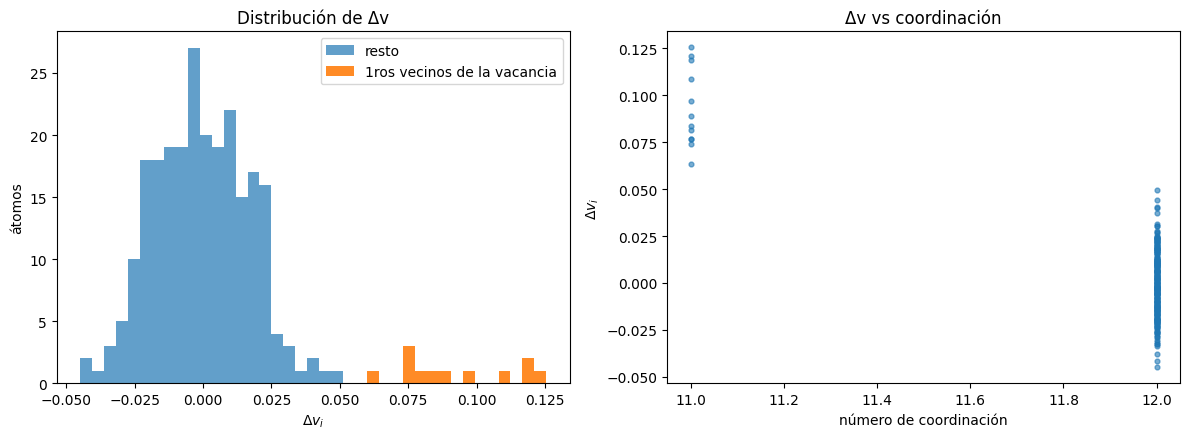

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

bins = torch.linspace(dv.min().item(), dv.max().item(), 40)
ax[0].hist(dv[~es_vecino_vac], bins=bins, alpha=0.7, label="resto")
ax[0].hist(dv[es_vecino_vac], bins=bins, alpha=0.9, label="1ros vecinos de la vacancia")
ax[0].set_xlabel(r"$\Delta v_i$"); ax[0].set_ylabel("átomos"); ax[0].legend()
ax[0].set_title("Distribución de Δv")

ax[1].scatter(coord, dv, s=12, alpha=0.6)
ax[1].set_xlabel("número de coordinación"); ax[1].set_ylabel(r"$\Delta v_i$")
ax[1].set_title("Δv vs coordinación")
plt.tight_layout(); plt.show()

La caja entera en 3D, con cada átomo coloreado por su Δv. Para un gráfico 3D se pide `projection="3d"` al crear el eje, y `ax.scatter(*pos.T)` desarma la matriz `(3, N)` en tres argumentos x, y, z. Con `cmap="coolwarm"` los Δv negativos quedan azules y los positivos rojos; `vmin` y `vmax` simétricos hacen que Δv = 0 sea blanco.

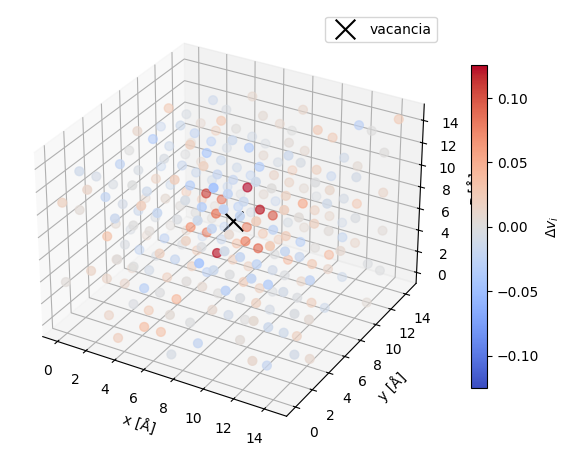

In [11]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(*pos_v.T, c=dv, cmap="coolwarm", s=40,
                vmin=-dv.abs().max(), vmax=dv.abs().max())
ax.scatter(*sitio_vacancia, marker="x", s=200, c="k", label="vacancia")
fig.colorbar(sc, shrink=0.6, label=r"$\Delta v_i$")
ax.set_xlabel("x [Å]"); ax.set_ylabel("y [Å]"); ax.set_zlabel("z [Å]")
ax.legend(); plt.show()

## Paso 9 · Armar el dataset y guardarlo

**Rasgos `x` de cada átomo:**

- **one-hot de la especie** (5 columnas). `F.one_hot(species, 5)` convierte el entero 2 en `[0, 0, 1, 0, 0]`. Se hace así porque si le paso el número 2 directo, la red pensaría que "Cr (2)" está entre "Co (1)" y "Cu (3)", y eso no significa nada.
- **coordinación** (1 columna). `unsqueeze(1)` pasa de forma `(N,)` a `(N, 1)` para poder pegarla como columna con `torch.cat(..., dim=1)`.

> **`torch.nn.functional` (`F`)**: funciones "sueltas" de redes (activaciones, pérdidas, `one_hot`), sin parámetros que aprender.
>
> **`pathlib.Path`**: manejo de rutas de archivos. `Path("datos").mkdir(exist_ok=True)` crea la carpeta si no existe.
>
> **`torch.save(dict, ruta)`**: guarda cualquier cosa de Python (diccionarios de tensores, números, listas) en un archivo `.pt`. Se lee con `torch.load`.

> **Ojo:** la coordinación ya le "avisa" al modelo dónde está la vacancia (da 11). Acá la dejo para practicar, pero el modelo de verdad no la va a tener: tiene que sacar esa información de la geometría.

In [12]:
import torch.nn.functional as F
from pathlib import Path

onehot = F.one_hot(species_v, num_classes=len(ELEMENTOS)).float()   # (N, 5)
x = torch.cat([onehot, coord.unsqueeze(1).float()], dim=1)          # (N, 6)
y = dv                                                              # (N,)

print("x:", x.shape, x.dtype, "| y:", y.shape, "| edge_index:", edge_index.shape)
print(x[:3])

Path("datos").mkdir(exist_ok=True)
torch.save({"pos": pos_v, "species": species_v, "x": x, "y": y,
            "edge_index": edge_index, "L": L, "a": a, "r_c": r_c,
            "elementos": ELEMENTOS, "vecino_vacancia": es_vecino_vac},
           "datos/01_fcc_vacancia.pt")
print("guardado en datos/01_fcc_vacancia.pt")

x: torch.Size([255, 6]) torch.float32 | y: torch.Size([255]) | edge_index: torch.Size([2, 3048])
tensor([[ 0.,  0.,  1.,  0.,  0., 12.],
        [ 0.,  0.,  0.,  0.,  1., 12.],
        [ 0.,  0.,  0.,  1.,  0., 12.]])
guardado en datos/01_fcc_vacancia.pt


## Paso 10 · Usar la GPU

En Colab: *Entorno de ejecución → Cambiar tipo de entorno → GPU*.

> **`device`**: dónde viven los tensores, `"cpu"` o `"cuda"` (GPU). `torch.cuda.is_available()` dice si hay GPU. Con `.to(device)` muevo un tensor de un lado al otro.

Regla para recordar: **todos los tensores de una operación tienen que estar en el mismo dispositivo**, si no, error. El código es el mismo; solo cambia dónde corre. `torch.allclose` compara dos tensores con una tolerancia, para verificar que GPU y CPU dan lo mismo.

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pos_dev = pos_v.to(device)
r_dev = distancias_pbc(pos_dev, L)
print(device, r_dev.device, "| mismo resultado que en CPU:",
      torch.allclose(r_dev.cpu(), r, atol=1e-5))

cpu cpu | mismo resultado que en CPU: True


## Lo que me llevo de este notebook

| Herramienta | Para qué la voy a reusar |
|---|---|
| broadcasting `a[:, None] - a[None]` | todas las distancias de una, sin loops |
| `d - L * round(d / L)` | imagen mínima con PBC |
| máscara booleana `t[mask]` | filtrar átomos (sacar la vacancia, elegir vecinos) |
| `mask.nonzero().T` | `edge_index` para grafos |
| `t.numpy()` / `torch.from_numpy` | ida y vuelta con freud y otras librerías |
| `F.one_hot` | codificar categorías (especies) |

## Para probar

- Subir σ a 0.15 Å. ¿Se pisan los dos histogramas? Ese es justo el problema que tiene que resolver la red.
- Poner una segunda vacancia lejos y ver si cambia el Δv de la primera.
- Agregar un intersticial en un sitio octaédrico (a/2, 0, 0) con `torch.cat([pos_v, nuevo[None]])` y ver el signo del Δv de los vecinos.
- Cambiar la matriz N×N por `freud.locality.AABBQuery(box, pts).query(pts, {"r_max": r_c, "exclude_ii": True})` y comprobar que da el mismo `edge_index`.